In [1]:
# downloaded from https://github.com/motionsignaltechnologies/reading-forge-DAS-segy-Apr2024
from ForgeSegyReader import read
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
st = read("/nfs/data/forge/RAW_DAS_16B_20240401_20240412/240403/dassei-013132-20240403T191740.sgy")
picks = pd.read_csv("results/picks/dassei-013132-20240403T191740.sgy.csv")

In [28]:
data = []
for tr in st:
    data.append(tr.data)
data = np.array(data)

decimation_factor = 3
data = data[:, ::decimation_factor]

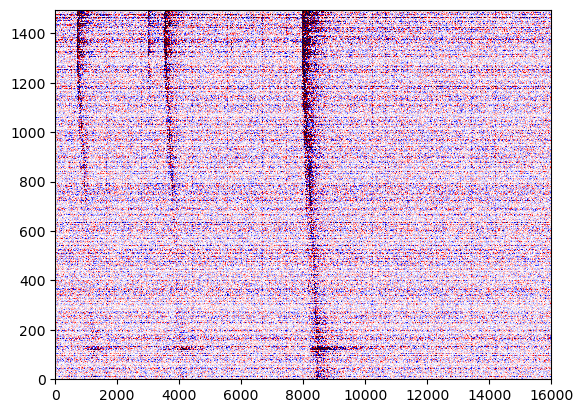

In [31]:
plt.figure()
vmax = np.percentile(np.abs(data), 99)
plt.pcolormesh(data, vmin=-vmax, vmax=vmax, cmap='seismic')


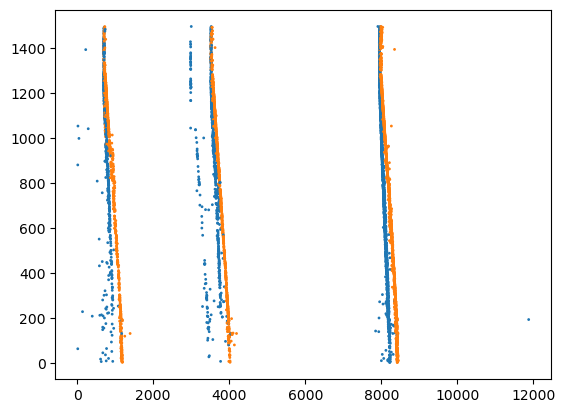

In [6]:
plt.figure()

color = lambda x: 'C0' if x == 'P' else 'C1'
plt.scatter(picks['phase_index'], picks['station_id'], c=picks['phase_type'].map(color), s=1)

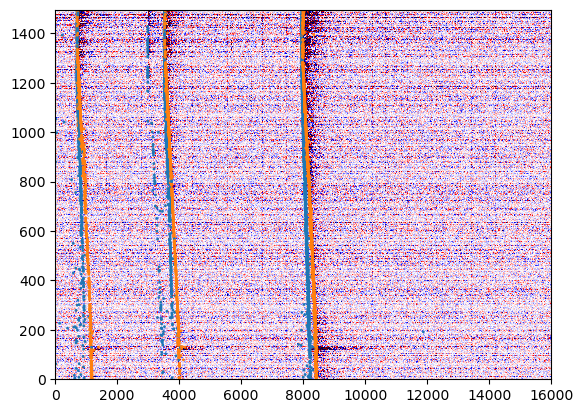

In [30]:
plt.figure()
vmax = np.percentile(np.abs(data), 99)
plt.pcolormesh(data, vmin=-vmax, vmax=vmax, cmap='seismic')

color = lambda x: 'C0' if x == 'P' else 'C1'
plt.scatter(picks['phase_index'], picks['station_id'], c=picks['phase_type'].map(color), s=1)